In [ ]:
#this dataset is converted from pdf into csv and only for testing

import camelot

# Read all tables from PDF
tables = camelot.read_pdf("../datasets/Market Watch-96.pdf", pages="all", flavor='stream')  # 'stream' works better for aligned text

# Check number of tables extracted
print(f"Total tables found: {len(tables)}")

# Preview first table
tables[0].df.head()

d:\Smart_Agri_System\venv\Lib\site-packages\pypdf\_crypt_providers\_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4
d:\Smart_Agri_System\venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (49.544, 748.25928, 582.8084, 866.481460841368)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


Total tables found: 4


,0
0,Jointly produced by:
1,"WFP-World Food Programme, Evidence, Policy and"
2,"Innovation Unit, Nepal"
3,MoALD-Ministry of Agriculture and Livestock De...
4,"(MoALD), Department of Agriculture (DoA), Market"


In [2]:
import pandas as pd

all_tables = [table.df for table in tables]  # list of dataframes
df = pd.concat(all_tables, ignore_index=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Jointly produced by:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"WFP-World Food Programme, Evidence, Policy and",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Innovation Unit, Nepal",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MoALD-Ministry of Agriculture and Livestock De...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(MoALD), Department of Agriculture (DoA), Market",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Rename columns to match your format
df.columns = ['date', 'crop', 'market', 'price']

# Remove empty rows
df = df.dropna(how='any')

# Convert price to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows with invalid date/price
df = df.dropna(subset=['date','price'])

ValueError: Length mismatch: Expected axis has 18 elements, new values have 4 elements

In [4]:
import camelot

tables = camelot.read_pdf("../datasets/Market Watch-96.pdf", pages="all", flavor='stream')
print(f"Total tables found: {len(tables)}")

# Preview each table to find the real data table
for i, table in enumerate(tables):
    print(f"\nTable {i} preview:")
    print(table.df.head())

d:\Smart_Agri_System\venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (49.544, 748.25928, 582.8084, 866.481460841368)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


Total tables found: 4

Table 0 preview:
                                                   0
0                               Jointly produced by:
1     WFP-World Food Programme, Evidence, Policy and
2                             Innovation Unit, Nepal
3  MoALD-Ministry of Agriculture and Livestock De...
4   (MoALD), Department of Agriculture (DoA), Market

Table 1 preview:
                                                   0
0                                     February 2020†
1                                         HIGHLIGHTS
2  In  February  2020,  retail  prices  of  most ...
3  remained  relatively  stable  or  experienced ...
4          commodities and an overall smooth supply.

Table 2 preview:
       0          1        2  3                     4  5  6   \
0                     Current                                  
1                                                              
2                       price     Change in price (%)*         
3          Commodity     (NRS   

In [5]:
# Pick the likely table
df = tables[2].df  # Table 2 seems like the actual data
df.head(10)         # Inspect the first 10 rows to see headers

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,,,Current,,,,,,,,,,,,,,,
1,,,,,,,,,,,,Current,,,,,,
2,,,price,,Change in price (%)*,,,Average change over,,,,,,Change in price (%)*,,,Average change over,
3,,Commodity,(NRS,,,,,,,,,price,,,,,,
4,Market,,,,,,,,,Market,Commodity,,,,,,,
5,,,per Kg/,,,,,,,,,(NRS per,,,,,,
6,,,,,,,,,,,,Kg/Lt.),,,,,,
7,,,Lt.),1 m,3 m,1 yr,,1m 3m 1yr,,,,,1 m,3 m,1 yr,,1m 3m 1yr,
8,,Major consumer markets,,,,,,,,,,,,,,,,
9,,,,,,,,,,,Coarse rice,42.0,5.0,20.0,13.5,►,▲,►


In [6]:
# Assume tables[2] contains this data
df = tables[2].df

# Skip first 9 rows of headers
df = df[9:].reset_index(drop=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,,,,,,,,,,,Coarse rice,42.0,5.0,20.0,13.5,►,▲,►
1,,Coarse rice,47.0,0.0,0.0,0.0,►,►,►,,,,,,,,,
2,,,,,,,,,,,Wheat flour,46.0,0.0,4.5,4.5,►,►,►
3,,,60.0,0.0,0.0,25.0,►,►,▲,,,,,,,,,
4,,Wheat flour,,,,,,,,,Soybean oil,147.0,0.0,11.4,7.3,►,▲,►


In [4]:
# Adjust based on your column index
df = df[[1, 2, 3, 4]]  # crop + 3 markets
df.columns = ['crop', 'Kathmandu', 'Biratnagar', 'Hetauda']
df.head()

NameError: name 'df' is not defined

In [3]:
df_long = df.melt(id_vars=['crop'], 
                  value_vars=['Kathmandu', 'Biratnagar', 'Hetauda'], 
                  var_name='market', 
                  value_name='price')

# Convert price to numeric
df_long['price'] = pd.to_numeric(df_long['price'], errors='coerce')

# Drop rows with missing prices
df_long = df_long.dropna(subset=['price'])

NameError: name 'df' is not defined

In [9]:
df_long['date'] = pd.to_datetime('2020-02-01')
df_long = df_long[['date','crop','market','price']]
df_long.head()

,date,crop,market,price
1,2020-02-01,Coarse rice,Kathmandu,47.0
3,2020-02-01,,Kathmandu,60.0
5,2020-02-01,Soybean oil,Kathmandu,140.0
7,2020-02-01,Chicken,Kathmandu,400.0
9,2020-02-01,Broken lentil,Kathmandu,110.0


In [11]:
df_long.to_csv("../datasets/market_prices_feb2020.csv", index=False)

NameError: name 'df_long' is not defined

In [15]:
#Loading the datasets and importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

data = pd.read_csv("../datasets/market_prices_feb2020.csv")
data.head()



,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
1,2020-02-01,NaN,Kathmandu,60.0
2,2020-02-01,Soybean oil,Kathmandu,140.0
3,2020-02-01,Chicken,Kathmandu,400.0
4,2020-02-01,Broken lentil,Kathmandu,110.0


In [16]:
data = data.dropna(subset=['crop'])  # remove NaN crops

# Keep only crop-related items
valid_crops = ['rice','wheat','maize','lentil']

data = data[data['crop'].str.lower().str.contains('|'.join(valid_crops))]

In [18]:
data.head()

,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
4,2020-02-01,Broken lentil,Kathmandu,110.0
6,2020-02-01,Coarse rice,Kathmandu,55.0
7,2020-02-01,Wheat flour,Kathmandu,60.0
12,2020-02-01,Coarse rice,Kathmandu,55.0


In [19]:
data.columns

Index(['date', 'crop', 'market', 'price'], dtype='str')

In [20]:
data.isnull().sum()

date      0
crop      0
market    0
price     0
dtype: int64

In [8]:
data.shape

(144, 4)

In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 66 entries, 0 to 142
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    66 non-null     str    
 1   crop    66 non-null     str    
 2   market  66 non-null     str    
 3   price   66 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.6 KB


In [23]:
#Importing libraries and loading different 3 datasets
# importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib


# Load datasets
data_kalimati1 = pd.read_csv("../datasets/kalimati_2013_2021.csv")
#data_kalimati2 = pd.read_csv("../datasets/kalimati_2021_2023.csv")
data_kalimati2 = pd.read_csv("../datasets/kalimati_2021_2023.csv", header=None)
#data_india = pd.read_csv("../datasets/indian_crop_price.csv")
data_local = pd.read_csv("../datasets/nepal_local_crop_price.csv")





In [51]:
#assigning proper columns name of kalimati2 dataset
data_kalimati2.columns = ['crop','date','unit','min_price','max_price','price']

In [52]:
#cleaning it properly kalimati2 dataset
data_kalimati2['market'] = 'Kalimati'
data_kalimati2['country'] = 'Nepal'

# Keep required columns
data_kalimati2 = data_kalimati2[['date','crop','market','price','country']]

In [53]:
#converting date format
data_kalimati2['date'] = pd.to_datetime(data_kalimati2['date'], errors='coerce')

In [54]:
#merging with first kalimati1 dataset
data_kalimati = pd.concat([data_kalimati1, data_kalimati2], ignore_index=True)

In [55]:
data_kalimati1.head()


,date,crop,market,price,country
0,2013-06-16T00:00:00,Tomato Big(Nepali),kalimati,37.5,nepal
1,2013-06-16T00:00:00,Tomato Small(Local),kalimati,29.0,nepal
2,2013-06-16T00:00:00,Potato Red,kalimati,20.5,nepal
3,2013-06-16T00:00:00,Potato White,kalimati,15.5,nepal
4,2013-06-16T00:00:00,Onion Dry (Indian),kalimati,29.0,nepal


In [56]:
data_kalimati2.head()

,date,crop,market,price,country
0,2021-01-05,Tomato Big(Indian),Kalimati,55,Nepal
1,2021-01-05,Tomato Small(Local),Kalimati,32.5,Nepal
2,2021-01-05,Tomato Small(Tunnel),Kalimati,32.5,Nepal
3,2021-01-05,Tomato Small(Indian),Kalimati,42.5,Nepal
4,2021-01-05,Tomato Small(Terai),Kalimati,42.5,Nepal


In [ ]:
#data_india.head()

NameError: name 'data_india' is not defined

In [60]:
data_local.head()

,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
1,2020-02-01,NaN,Kathmandu,60.0
2,2020-02-01,Soybean oil,Kathmandu,140.0
3,2020-02-01,Chicken,Kathmandu,400.0
4,2020-02-01,Broken lentil,Kathmandu,110.0


In [29]:
#standardize both kalimati datasets columns
def clean_kalimati(df):
    df = df.copy()
    
    df.rename(columns={
        'Commodity': 'crop',
        'Date': 'date',
        'Average': 'price'
    }, inplace=True)
    
    df['market'] = 'Kalimati'
    df['country'] = 'Nepal'
    
    return df[['date','crop','market','price','country']]


data_kalimati1 = clean_kalimati(data_kalimati1)
data_kalimati2 = clean_kalimati(data_kalimati2)

# Merge both Kalimati datasets
data_kalimati = pd.concat([data_kalimati1, data_kalimati2], ignore_index=True)

In [62]:
#printing both kalimati datasets columns
print(data_kalimati1.columns)
print(data_kalimati2.columns)

Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')
Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')


In [ ]:
#standardize indian datasets
data_india = data_india.copy()

# Adjust based on your CSV columns
data_india.rename(columns={
    'Crop': 'crop',
    'Date': 'date',
    'Price': 'price'
}, inplace=True)

# Convert INR → NPR
data_india['price'] = data_india['price'] * 1.6

data_india['market'] = 'IndiaMarket'
data_india['country'] = 'India'

data_india = data_india[['date','crop','market','price','country']]

In [15]:
data_india.columns

Index(['State', 'Crop', 'CostCultivation', 'CostCultivation2', 'Production',
       'Yield', 'Temperature', 'RainFall Annual', 'Price'],
      dtype='str')

In [63]:
data_local = data_local.copy()

# Remove missing crops
data_local = data_local.dropna(subset=['crop'])

# Keep only relevant crops
valid_crops = ['rice','wheat','maize','lentil']
data_local = data_local[data_local['crop'].str.lower().str.contains('|'.join(valid_crops))]

data_local['country'] = 'Nepal'

data_local = data_local[['date','crop','market','price','country']]

In [64]:
data_local.columns

Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')

In [65]:
data_local.items

<bound method DataFrame.items of            date           crop     market  price country
0    2020-02-01    Coarse rice  Kathmandu   47.0   Nepal
4    2020-02-01  Broken lentil  Kathmandu  110.0   Nepal
6    2020-02-01    Coarse rice  Kathmandu   55.0   Nepal
7    2020-02-01    Wheat flour  Kathmandu   60.0   Nepal
12   2020-02-01    Coarse rice  Kathmandu   55.0   Nepal
..          ...            ...        ...    ...     ...
133  2020-02-01    Wheat flour    Hetauda    0.0   Nepal
136  2020-02-01  Broken lentil    Hetauda    0.0   Nepal
138  2020-02-01    Coarse rice    Hetauda   18.4   Nepal
139  2020-02-01    Wheat flour    Hetauda    0.0   Nepal
142  2020-02-01  Broken lentil    Hetauda    5.3   Nepal

[66 rows x 5 columns]>

In [30]:
# Combine all datasets
df = pd.concat([data_kalimati, data_local], ignore_index=True)

# Convert date format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['date','price','crop'])

# Reset index
df = df.reset_index(drop=True)

df.head()

,date,crop,market,price,country
0,2013-06-16,Tomato Big(Nepali),Kalimati,37.5,Nepal
1,2013-06-16,Tomato Small(Local),Kalimati,29.0,Nepal
2,2013-06-16,Potato Red,Kalimati,20.5,Nepal
3,2013-06-16,Potato White,Kalimati,15.5,Nepal
4,2013-06-16,Onion Dry (Indian),Kalimati,29.0,Nepal


In [40]:
print("Shape:", df.shape)
print(df['country'].value_counts())
print(df['crop'].nunique())

Shape: (242485, 5)
country
Nepal    242485
Name: count, dtype: int64
135


In [27]:
df_price = df.copy()
df_price.info()
df_price.describe()
df_price['crop'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 242485 entries, 0 to 242484
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     242485 non-null  datetime64[us]
 1   crop     242485 non-null  str           
 2   market   242485 non-null  str           
 3   price    242485 non-null  object        
 4   country  242485 non-null  str           
dtypes: datetime64[us](1), object(1), str(3)
memory usage: 9.3+ MB


crop
Cauli Local             3216
Ginger                  3216
Cabbage(Local)          3213
Chilli Dry              3213
Raddish White(Local)    3212
                        ... 
Water Melon(Dotted)       53
Maize                     24
Sweet Lime                20
Sarifa                    18
Musk Melon                10
Name: count, Length: 135, dtype: int64

In [30]:
#checking the data values of Item column
df["crop"].unique()

<StringArray>
[  'tomato big(nepali)',  'tomato small(local)',           'potato red',
         'potato white',   'onion dry (indian)',        'carrot(local)',
       'cabbage(local)',          'cauli local',          'raddish red',
 'raddish white(local)',
 ...
       'cabbage(terai)',   'cauli local(jyapu)', 'pointed gourd(terai)',
        'grapes(black)',                 'kiwi',      'mango(calcutte)',
        'mango(chousa)',               'sarifa',              'avocado',
                 'amla']
Length: 135, dtype: str

In [29]:
#df["crop"] = df["crop"].str.lower()
df['crop'] = df['crop'].str.lower().str.strip()

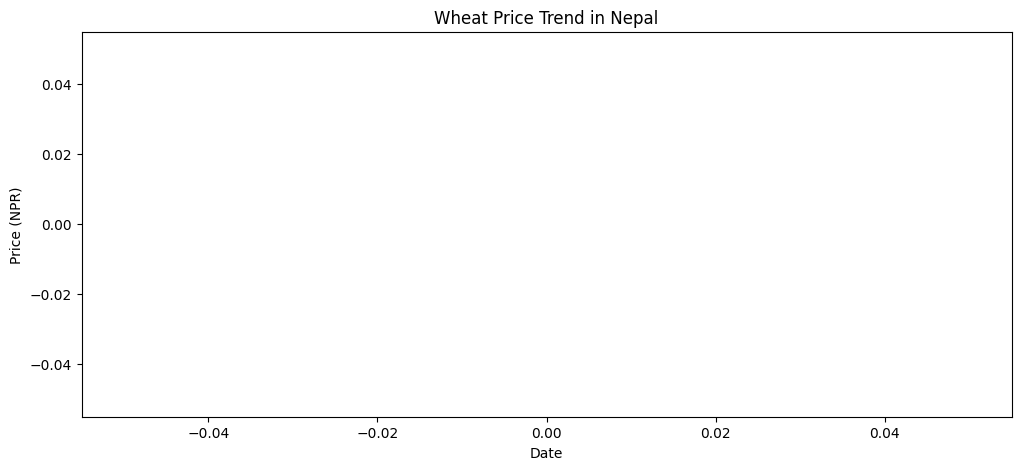

In [31]:
#EDA: time-series plot per crop

# Example: Wheat price trend
wheat = df_price[df_price['crop'].str.lower() == 'wheat']
wheat = wheat.sort_values('date')

plt.figure(figsize=(12,5))
sns.lineplot(data=wheat, x='date', y='price')
plt.title("Wheat Price Trend in Nepal")
plt.xlabel("Date")
plt.ylabel("Price (NPR)")
plt.show()

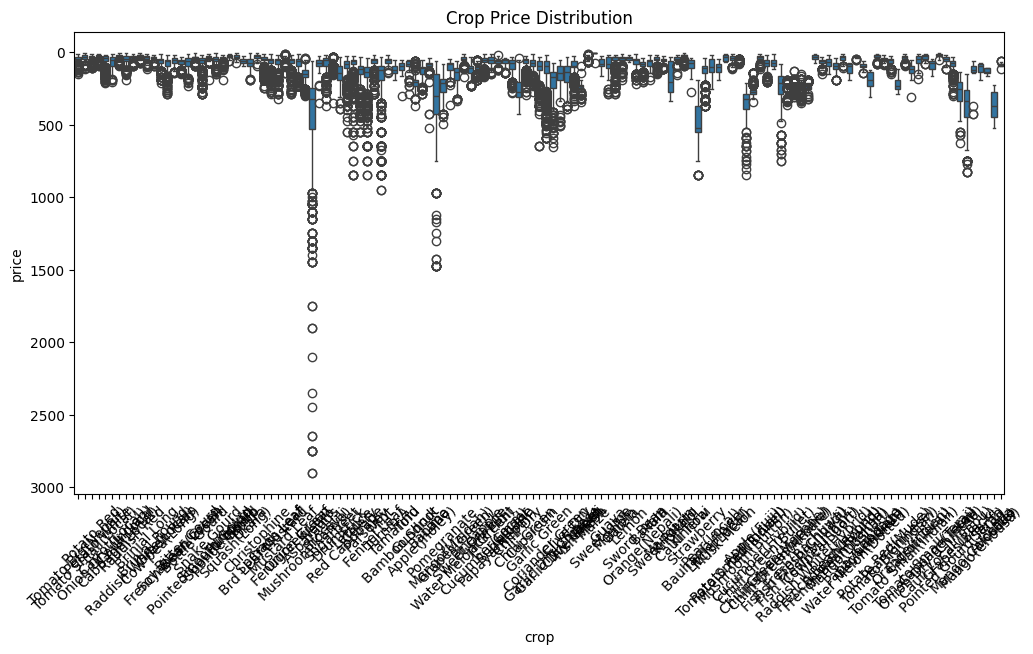

In [32]:
#crop price distribution
plt.figure(figsize=(12,6))
sns.boxplot(x='crop', y='price', data=df_price)
plt.title("Crop Price Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# #
# df_price = df_price.sort_values(['crop','date'])
# df_price['price_lag_1'] = df_price.groupby('crop')['price'].shift(1)
# df_price['price_lag_7'] = df_price.groupby('crop')['price'].shift(7)
# df_price['price_lag_30'] = df_price.groupby('crop')['price'].shift(30)

In [ ]:
# df_price['price_roll_7'] = df_price.groupby('crop')['price'].transform(lambda x: x.rolling(7).mean())
# df_price['price_roll_30'] = df_price.groupby('crop')['price'].transform(lambda x: x.rolling(30).mean())

In [ ]:
# df_price['month'] = df_price['date'].dt.month
# df_price['day'] = df_price['date'].dt.day
# df_price['weekday'] = df_price['date'].dt.weekday

In [ ]:
# df_price = df_price.dropna(subset=['price_lag_1','price_lag_7','price_lag_30','price_roll_7','price_roll_30'])

In [ ]:
# #from sklearn.model_selection import train_test_split

# features = ['price_lag_1','price_lag_7','price_lag_30','price_roll_7','price_roll_30','month','day','weekday']
# target = 'price'

# X = df_price[features]
# y = df_price[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
#the below one is complelete code

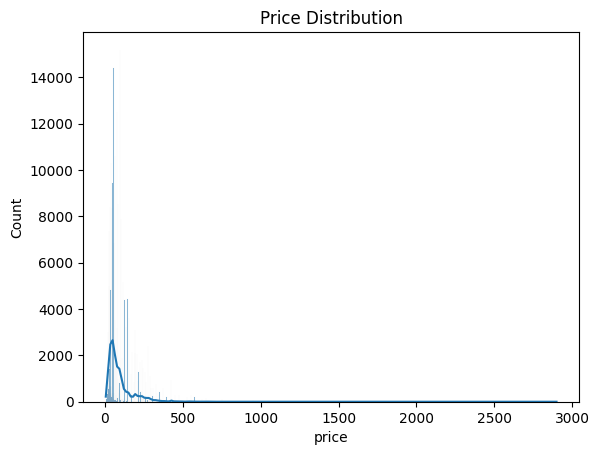

In [33]:
#visualization of price distribution
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

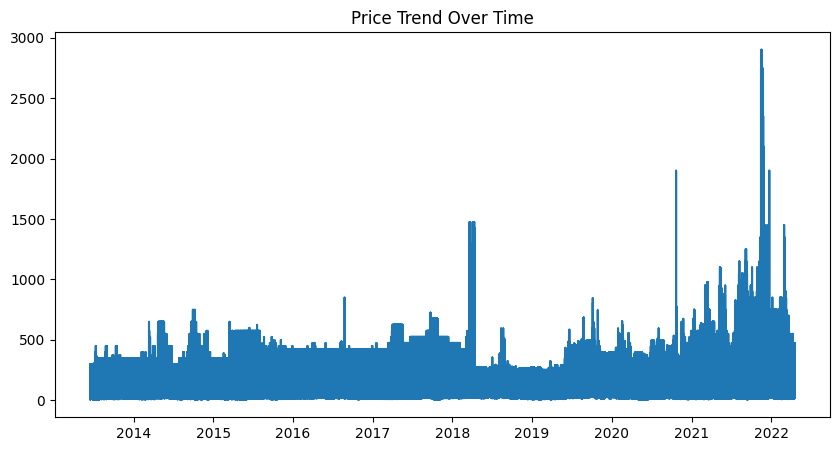

In [34]:
#visualization of price over time
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['price'])
plt.title("Price Trend Over Time")
plt.show()

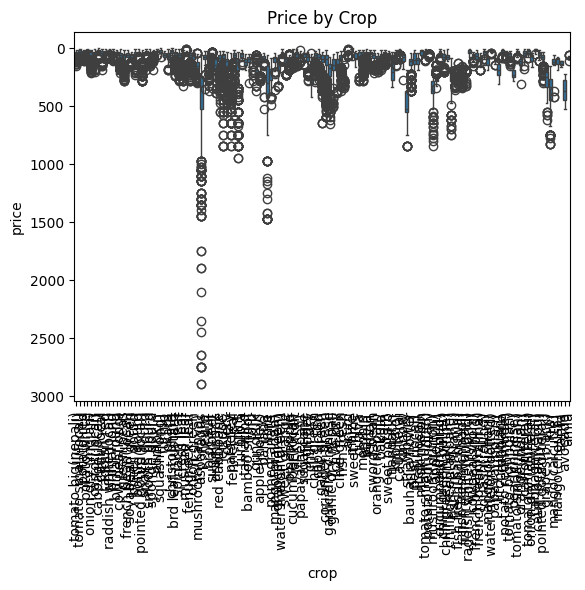

In [35]:
#visualization of price by crop
sns.boxplot(x='crop', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Price by Crop")
plt.show()

In [36]:
#features selection or engineering
# Time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Encode categorical variables
df = pd.get_dummies(df, columns=['crop','market','country'])

# Features & target
X = df.drop(['date','price'], axis=1)
y = df['price']

In [43]:
#train and test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'y' is not defined

In [38]:
#import joblib

joblib.dump(X_train.columns.tolist(), "../ml_models/market_prediction/price_features.pkl")

print("Feature columns saved!")

Feature columns saved!


In [40]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [41]:
#Evaluation and comparison of different models
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))
    print("-----------")

evaluate("Linear Regression", lr)
evaluate("Random Forest", rf)
evaluate("Gradient Boosting", gb)

Linear Regression
RMSE: 54.52915889161361
R2: 0.6630436359848907
-----------
Random Forest
RMSE: 22.064943403201323
R2: 0.9448276222198072
-----------
Gradient Boosting
RMSE: 52.90775838398086
R2: 0.6827842159942752
-----------


In [42]:
#saving the best model
final_model = rf  # best random forest

joblib.dump(final_model, "../ml_models/market_prediction/price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [2]:
import joblib

# Load the feature columns
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")

# Display all feature names
for i, col in enumerate(feature_columns):
    print(i, col)

0 year
1 month
2 crop_amla
3 crop_apple(fuji)
4 crop_apple(jholey)
5 crop_arum
6 crop_asparagus
7 crop_avocado
8 crop_bakula
9 crop_bamboo shoot
10 crop_banana
11 crop_barela
12 crop_bauhania flower
13 crop_bitter gourd
14 crop_bottle gourd
15 crop_brd leaf mustard
16 crop_brinjal long
17 crop_brinjal round
18 crop_brocauli
19 crop_cabbage
20 crop_cabbage(local)
21 crop_cabbage(terai)
22 crop_capsicum
23 crop_carrot(local)
24 crop_carrot(terai)
25 crop_cauli local
26 crop_cauli local(jyapu)
27 crop_cauli terai
28 crop_celery
29 crop_chilli dry
30 crop_chilli green
31 crop_chilli green(akbare)
32 crop_chilli green(bullet)
33 crop_chilli green(machhe)
34 crop_christophine
35 crop_clive dry
36 crop_clive green
37 crop_coriander green
38 crop_cow pea(long)
39 crop_cowpea(short)
40 crop_cress leaf
41 crop_cucumber(hybrid)
42 crop_cucumber(local)
43 crop_drumstick
44 crop_fennel leaf
45 crop_fenugreek leaf
46 crop_fish fresh
47 crop_fish fresh(bachuwa)
48 crop_fish fresh(chhadi)
49 crop_fish

In [3]:
# Get all crop columns
crop_cols = [col for col in feature_columns if col.startswith('crop_')]
print("Crop columns:", crop_cols)

# Get all market columns
market_cols = [col for col in feature_columns if col.startswith('market_')]
print("Market columns:", market_cols)

# Get all country columns
country_cols = [col for col in feature_columns if col.startswith('country_')]
print("Country columns:", country_cols)

Crop columns: ['crop_amla', 'crop_apple(fuji)', 'crop_apple(jholey)', 'crop_arum', 'crop_asparagus', 'crop_avocado', 'crop_bakula', 'crop_bamboo shoot', 'crop_banana', 'crop_barela', 'crop_bauhania flower', 'crop_bitter gourd', 'crop_bottle gourd', 'crop_brd leaf mustard', 'crop_brinjal long', 'crop_brinjal round', 'crop_brocauli', 'crop_cabbage', 'crop_cabbage(local)', 'crop_cabbage(terai)', 'crop_capsicum', 'crop_carrot(local)', 'crop_carrot(terai)', 'crop_cauli local', 'crop_cauli local(jyapu)', 'crop_cauli terai', 'crop_celery', 'crop_chilli dry', 'crop_chilli green', 'crop_chilli green(akbare)', 'crop_chilli green(bullet)', 'crop_chilli green(machhe)', 'crop_christophine', 'crop_clive dry', 'crop_clive green', 'crop_coriander green', 'crop_cow pea(long)', 'crop_cowpea(short)', 'crop_cress leaf', 'crop_cucumber(hybrid)', 'crop_cucumber(local)', 'crop_drumstick', 'crop_fennel leaf', 'crop_fenugreek leaf', 'crop_fish fresh', 'crop_fish fresh(bachuwa)', 'crop_fish fresh(chhadi)', 'cro

In [4]:
# Load the trained model
price_model = joblib.load("../ml_models/market_prediction/price_model.pkl")

# Check how many input features it expects
print("Number of features the model expects:", price_model.n_features_in_)

Number of features the model expects: 139


In [39]:
#prediction with price_model1.pkl with feature column
import pandas as pd
import joblib

# Load model + features
price_model = joblib.load("../ml_models/market_prediction/price_model.pkl")
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")

# Create empty DataFrame with all zeros
sample = pd.DataFrame(columns=feature_columns)
sample.loc[0] = 0

# Set the values we want
sample['year'] = 2026
sample['month'] = 4

# Only the crop, market, country of interest = 1
#sample['crop_banana'] = 1
sample['crop_maize'] = 1
sample['market_Kalimati'] = 1
sample['country_Nepal'] = 1

# Predict
prediction = price_model.predict(sample)
print("Predicted Market Price:", round(prediction[0], 2), "NPR/kg")

Predicted Market Price: 75.86 NPR/kg


In [10]:
import joblib

feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")
crop_columns = [c for c in feature_columns if c.startswith('crop_')]
print(crop_columns)

['crop_amla', 'crop_apple(fuji)', 'crop_apple(jholey)', 'crop_arum', 'crop_asparagus', 'crop_avocado', 'crop_bakula', 'crop_bamboo shoot', 'crop_banana', 'crop_barela', 'crop_bauhania flower', 'crop_bitter gourd', 'crop_bottle gourd', 'crop_brd leaf mustard', 'crop_brinjal long', 'crop_brinjal round', 'crop_brocauli', 'crop_cabbage', 'crop_cabbage(local)', 'crop_cabbage(terai)', 'crop_capsicum', 'crop_carrot(local)', 'crop_carrot(terai)', 'crop_cauli local', 'crop_cauli local(jyapu)', 'crop_cauli terai', 'crop_celery', 'crop_chilli dry', 'crop_chilli green', 'crop_chilli green(akbare)', 'crop_chilli green(bullet)', 'crop_chilli green(machhe)', 'crop_christophine', 'crop_clive dry', 'crop_clive green', 'crop_coriander green', 'crop_cow pea(long)', 'crop_cowpea(short)', 'crop_cress leaf', 'crop_cucumber(hybrid)', 'crop_cucumber(local)', 'crop_drumstick', 'crop_fennel leaf', 'crop_fenugreek leaf', 'crop_fish fresh', 'crop_fish fresh(bachuwa)', 'crop_fish fresh(chhadi)', 'crop_fish fresh(m

In [21]:
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")
[r for r in feature_columns if "rice" in r.lower()]

[]

In [42]:
# Check if rice is in the merged dataframe
df[df['crop'].str.lower().str.contains('rice')]

,date,crop,market,price,country


In [43]:
df = pd.concat([data_kalimati, data_local], ignore_index=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date','price','crop'])
df['crop'] = df['crop'].str.strip().str.lower()
df.reset_index(drop=True, inplace=True)

# Filter local crops
df[df['crop'].isin(['rice','wheat','maize','lentil'])]

,date,crop,market,price,country
772,2013-06-30,maize,Kalimati,5.5,Nepal
841,2013-07-01,maize,Kalimati,6.0,Nepal
1188,2013-07-09,maize,Kalimati,6.5,Nepal
1259,2013-07-10,maize,Kalimati,6.5,Nepal
1328,2013-07-11,maize,Kalimati,6.5,Nepal
1398,2013-07-12,maize,Kalimati,6.5,Nepal
1468,2013-07-14,maize,Kalimati,6.5,Nepal
1536,2013-07-15,maize,Kalimati,7.5,Nepal
1605,2013-07-16,maize,Kalimati,6.5,Nepal
1675,2013-07-17,maize,Kalimati,6.5,Nepal


In [47]:
# Normalize crop names
data_local['crop'] = data_local['crop'].str.strip().str.lower()
data_kalimati['crop'] = data_kalimati['crop'].str.strip().str.lower()

# Filter only relevant crops (optional)
valid_crops = ['rice','wheat','maize','lentil']
data_local = data_local[data_local['crop'].str.contains('|'.join(valid_crops))]

# Add missing columns if needed
data_local['country'] = 'Nepal'
data_local['market'] = data_local.get('market', 'LocalMarket')

# Keep consistent column order
data_local = data_local[['date','crop','market','price','country']]

# Merge datasets
df = pd.concat([data_kalimati, data_local], ignore_index=True)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date','price','crop']).reset_index(drop=True)

# Check local crops are included
df[df['crop'].str.contains('rice|wheat|lentil|maize')]

,date,crop,market,price,country
772,2013-06-30,maize,Kalimati,5.5,Nepal
841,2013-07-01,maize,Kalimati,6.0,Nepal
1188,2013-07-09,maize,Kalimati,6.5,Nepal
1259,2013-07-10,maize,Kalimati,6.5,Nepal
1328,2013-07-11,maize,Kalimati,6.5,Nepal
1398,2013-07-12,maize,Kalimati,6.5,Nepal
1468,2013-07-14,maize,Kalimati,6.5,Nepal
1536,2013-07-15,maize,Kalimati,7.5,Nepal
1605,2013-07-16,maize,Kalimati,6.5,Nepal
1675,2013-07-17,maize,Kalimati,6.5,Nepal


In [48]:
# Normalize crop names
data_local['crop'] = data_local['crop'].str.strip().str.lower()
data_kalimati['crop'] = data_kalimati['crop'].str.strip().str.lower()

# Filter only relevant crops
valid_crops = ['rice','wheat','maize','lentil']
data_local = data_local[data_local['crop'].str.contains('|'.join(valid_crops))]

# Add missing columns if needed
data_local['country'] = 'Nepal'
data_local['market'] = data_local.get('market', 'LocalMarket')

# Reorder columns to match Kalimati
data_local = data_local[['date','crop','market','price','country']]

# Merge datasets
df = pd.concat([data_kalimati, data_local], ignore_index=True)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date','price','crop']).reset_index(drop=True)

# Check that local crops are included
df[df['market'] != 'Kalimati'].head(10)

,date,crop,market,price,country


In [42]:
#prediction and testing the output with trained models
import pandas as pd
import joblib

# Load trained model and feature columns
price_model = joblib.load("../ml_models/market_prediction/price_model.pkl")
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")

# Create sample with all zeros
sample = pd.DataFrame(columns=feature_columns)
sample.loc[0] = 0

# Set the actual values
sample['year'] = 2026
sample['month'] = 4

# One-hot for crop, market, country
# Make sure the names exactly match your feature_columns
sample['crop_tomato big(nepali)'] = 1
sample['market_Kalimati'] = 1
sample['country_Nepal'] = 1

# Predict
prediction = price_model.predict(sample)

print("Predicted Market Price:", round(prediction[0], 2), "NPR/kg")

Predicted Market Price: 59.45 NPR/kg


In [50]:
import joblib

feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")
print([c for c in feature_columns if "rice" in c.lower()])
print([c for c in feature_columns if "kathmandu" in c.lower()])
print([c for c in feature_columns if "nepal" in c.lower()])

[]
[]
['crop_garlic dry nepali', 'crop_orange(nepali)', 'crop_papaya(nepali)', 'crop_tomato big(nepali)', 'country_Nepal']


In [ ]:
#making other one single model


import pandas as pd

# Combine all datasets
df = pd.concat([data_kalimati, data_local], ignore_index=True)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['date','price','crop','market'])

# Reset index
df = df.reset_index(drop=True)

In [67]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib
import numpy as np

# Time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Features & target
X = df[['year','month','crop','market','country']]
y = df['price']

# OneHotEncoder for categorical columns
categorical_features = ['crop','market','country']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # keep year and month
)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Create pipeline
price_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train
price_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = price_pipeline.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 22.088908961489008
R2: 0.9447077075772208


In [69]:
joblib.dump(price_pipeline, "../ml_models/market_prediction/price_model2.pkl")
print("Pipeline with features and model saved!")

Pipeline with features and model saved!


In [ ]:
# Load pipeline
import joblib
price_model = joblib.load("../ml_models/market_prediction/price_model2.pkl")

# Example prediction
sample = pd.DataFrame([{
    "year": 2026,
    "month": 4,
    "crop": "rice",
    "market": "Kalimati",
    "country": "Nepal"
}])

prediction = price_model.predict(sample)
print("Predicted Market Price:", round(prediction[0],2), "NPR/kg")

Predicted Market Price: 71.83 NPR/kg


In [31]:
import pandas as pd
import joblib

# 1. Reload your merged dataset
df = pd.concat([data_kalimati, data_local], ignore_index=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date','price','crop'])
df = df.reset_index(drop=True)

# 2. Feature engineering (same as training)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Ensure all crops you want are included
all_crops = ['rice','wheat','maize']  # add more if needed
for c in all_crops:
    if c not in df['crop'].unique():
        df = pd.concat([df, pd.DataFrame({'date':[pd.Timestamp.now()],
                                          'crop':[c],
                                          'market':['dummy'],
                                          'price':[0],
                                          'country':['Nepal']})], ignore_index=True)

# 3. Encode categorical variables
df = pd.get_dummies(df, columns=['crop','market','country'])

# 4. Get feature columns
X = df.drop(['date','price'], axis=1)
feature_columns = X.columns.tolist()

# 5. Save updated feature columns
joblib.dump(feature_columns, "../ml_models/market_prediction/price_features2.pkl")
print("Updated feature columns saved!")

Updated feature columns saved!


In [48]:
#again from scratch  for finalizing
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample



data_kalimati1 = pd.read_csv("../datasets/kalimati_2013_2021.csv")
data_kalimati2 = pd.read_csv("../datasets/kalimati_2021_2023.csv")
data_local = pd.read_csv("../datasets/nepal_local_crop_price.csv")

In [57]:
def clean_kalimati(df):
    df = df.copy()
    
    df.rename(columns={
        'Commodity': 'crop',
        'Date': 'date',
        'Average': 'price'
    }, inplace=True)
    
    df['market'] = 'kalimati'
    df['country'] = 'nepal'
    
    return df[['date','crop','market','price','country']]

data_kalimati1 = clean_kalimati(data_kalimati1)
data_kalimati2 = clean_kalimati(data_kalimati2)

data_kalimati = pd.concat([data_kalimati1, data_kalimati2], ignore_index=True)

In [58]:
data_local = data_local.copy()

data_local['country'] = 'nepal'

data_local = data_local[['date','crop','market','price','country']]

In [59]:
new_data = pd.DataFrame([
    ['2024-01-01','rice','kathmandu',52,'nepal'],
    ['2024-01-02','rice','kathmandu',55,'nepal'],
    ['2024-01-03','wheat','kathmandu',48,'nepal'],
    ['2024-01-04','maize','kathmandu',35,'nepal'],
    ['2024-01-05','lentil','kathmandu',95,'nepal'],
    
    ['2024-02-01','rice','hetauda',50,'nepal'],
    ['2024-02-02','wheat','hetauda',45,'nepal'],
    ['2024-02-03','maize','hetauda',32,'nepal'],
    ['2024-02-04','lentil','hetauda',90,'nepal'],

    ['2024-01-01','rice','kathmandu',52,'nepal'],
    ['2024-01-02','rice','kathmandu',55,'nepal'],
    ['2024-01-03','wheat','kathmandu',48,'nepal'],
    ['2024-01-04','maize','kathmandu',35,'nepal'],
    ['2024-01-05','lentil','kathmandu',95,'nepal'],

    ['2025-01-01','rice','kathmandu',52,'nepal'],
    ['2025-01-02','rice','kathmandu',55,'nepal'],
    ['2025-01-03','wheat','kathmandu',48,'nepal'],
    ['2025-01-04','maize','kathmandu',35,'nepal'],
    ['2025-01-05','lentil','kathmandu',95,'nepal'],

    ['2024-02-01','rice','hetauda',50,'nepal'],
    ['2024-02-02','wheat','hetauda',45,'nepal'],
    ['2024-02-03','maize','hetauda',32,'nepal'],
    ['2024-02-04','lentil','hetauda',90,'nepal'],

    ['2024-02-01','rice','hetauda',50,'nepal'],
    ['2024-02-02','wheat','hetauda',45,'nepal'],
    ['2024-02-03','maize','hetauda',32,'nepal'],
    ['2024-02-04','lentil','hetauda',90,'nepal'],

    ['2026-01-01','rice','kathmandu',52,'nepal'],
    ['2026-01-02','rice','kathmandu',55,'nepal'],
    ['2026-01-03','wheat','kathmandu',48,'nepal'],
    ['2026-01-04','maize','kathmandu',35,'nepal'],
    ['2026-01-05','lentil','kathmandu',95,'nepal'],
], columns=['date','crop','market','price','country'])

In [60]:
df = pd.concat([data_kalimati, data_local, new_data], ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date','price','crop','market'])
df = df.reset_index(drop=True)

In [79]:
df['crop'] = df['crop'].str.strip().str.lower()
df['market'] = df['market'].str.strip().str.lower()
df['country'] = df['country'].str.strip().str.lower()

df['crop'] = df['crop'].replace({
    'coarse rice': 'rice',
    'wheat flour': 'wheat',
    'broken lentil': 'lentil'
})

In [ ]:

#Balancing the datasets

# df_kalimati = df[df['market'] == 'kalimati']
# df_other = df[df['market'] != 'kalimati']

# df_other_up = resample(df_other,
#                       replace=True,
#                       n_samples=len(df_kalimati),
#                       random_state=42)

# df = pd.concat([df_kalimati, df_other_up])



from sklearn.utils import resample

df_kalimati = df[df['market'] == 'kalimati']
df_other = df[df['market'] != 'kalimati']

df_other_up = resample(
    df_other,
    replace=True,
    n_samples=len(df_kalimati),
    random_state=42
)

df = pd.concat([df_kalimati, df_other_up])

In [80]:
print(df.shape)
print(df['crop'].value_counts())
print(df['market'].value_counts())

(587280, 5)
crop
rice                   52275
potato                 52155
chicken                52122
wheat                  45979
lentil                 45619
                       ...  
tree tomato              109
water melon(dotted)       64
maize                     24
sweet lime                23
musk melon                10
Name: count, Length: 142, dtype: int64
market
kalimati      293640
kathmandu      98170
hetauda        97801
biratnagar     97669
Name: count, dtype: int64


In [88]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

X = df[['year','month','crop','market','country']]
y = df['price']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['crop','market','country'])
], remainder='passthrough')

In [91]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "GradientBoost": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = (rmse, r2)
    print(name, "RMSE:", rmse, "R2:", r2)

Linear RMSE: 51.478430459308406 R2: 0.6874349885253752
RandomForest RMSE: 22.640403795460937 R2: 0.9395413975514008
GradientBoost RMSE: 51.99530665004018 R2: 0.6811267743611971


In [92]:
final_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100))
])

final_model.fit(X_train, y_train)

joblib.dump(final_model, "../ml_models/market_prediction/price_model2.pkl")

print("Model saved!")

Model saved!


In [ ]:
#prediction with sample input data with price_model2.pkl
import joblib
import pandas as pd

model = joblib.load("../ml_models/market_prediction/price_model2.pkl")
#model2 = joblib.load("../ml_models/market_prediction/price_model.pkl")
#final_model = (model + model2)/2

sample = pd.DataFrame([{
    "year": 2026,
    "month": 4,
    "crop": "rice",
    "market": "kathmandu",
    "country": "nepal"
}])

prediction = model.predict(sample)

#prediction = model.predict(sample)
print("Predicted Price:", round(prediction[0],2), "NPR/kg")

Predicted Price: 71.83 NPR/kg


In [ ]:
#price prediction with both models

# import joblib
# import pandas as pd

# # Load both pipeline models
# model1 = joblib.load("../ml_models/market_prediction/price_model2.pkl")
# model2 = joblib.load("../ml_models/market_prediction/price_model.pkl")

# # Create a sample input DataFrame
# sample = pd.DataFrame([{
#     "year": 2026,
#     "month": 4,
#     "crop": "rice",
#     "market": "kathmandu",
#     "country": "nepal"
# }])

# # Predict with both models
# pred1 = model1.predict(sample)[0]
# pred2 = model2.predict(sample)[0]

# # Average predictions for final result
# final_pred = (pred1 + pred2) / 2

# print("Prediction from Model 1:", round(pred1, 2), "NPR/kg")
# print("Prediction from Model 2:", round(pred2, 2), "NPR/kg")
# print("Final Averaged Prediction:", round(final_pred, 2), "NPR/kg")





import joblib
import pandas as pd

# Load models
model1 = joblib.load("../ml_models/market_prediction/price_model2.pkl")  # pipeline
model2 = joblib.load("../ml_models/market_prediction/price_model.pkl")   # raw RF

# Load the feature columns used in model2
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")

# Sample input
sample_raw = pd.DataFrame([{
    "year": 2026,
    "month": 4,
    "crop": "banana",
    "market": "Kathmandu",
    "country": "Nepali"
}])

# -----------------------------
# Prediction using pipeline (model1)
pred1 = model1.predict(sample_raw)[0]

# -----------------------------
# Prediction using raw RF (model2)
# We need to one-hot encode manually to match feature_columns
sample_encoded = pd.get_dummies(sample_raw, columns=['crop','market','country'])

# Add any missing columns from feature_columns with 0
for col in feature_columns:
    if col not in sample_encoded.columns:
        sample_encoded[col] = 0

# Reorder columns to match feature_columns exactly
sample_encoded = sample_encoded[feature_columns]

pred2 = model2.predict(sample_encoded)[0]

# Average predictions
final_pred = (pred1 + pred2) / 2

print("Prediction from Model 1 (pipeline):", round(pred1,2))
print("Prediction from Model 2 (raw RF):", round(pred2,2))
print("Final Averaged Prediction:", round(final_pred,2))

Prediction from Model 1 (pipeline): 131.23
Prediction from Model 2 (raw RF): 132.25
Final Averaged Prediction: 131.74


C:\Users\MOHID AALAM\AppData\Local\Temp\ipykernel_4748\1220380354.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_encoded[col] = 0


In [ ]:
#price prediction with all 2 model and features columns

import joblib
import pandas as pd

# Load models
model1 = joblib.load("../ml_models/market_prediction/price_model2.pkl")  # pipeline
model2 = joblib.load("../ml_models/market_prediction/price_model.pkl")   # raw RF

# Load the feature columns used in model2
feature_columns = joblib.load("../ml_models/market_prediction/price_features.pkl")

# Sample input (you can change crop, market, year, month, country)
sample_raw = pd.DataFrame([{
    "year": 2026,
    "month": 4,
    "crop": "banana",
    "market": "Kathmandu",
    "country": "Nepal"
}])

# -----------------------------
# Prediction using pipeline (model1)
pred1 = model1.predict(sample_raw)[0]

# -----------------------------
# Prediction using raw RF (model2)
# Create a dataframe with all feature columns
sample_encoded = pd.DataFrame(0, index=[0], columns=feature_columns)

# Fill in the one-hot values for this sample
crop_col = f"crop_{sample_raw['crop'][0].lower()}"
market_col = f"market_{sample_raw['market'][0]}"
country_col = f"country_{sample_raw['country'][0]}"

for col in [crop_col, market_col, country_col]:
    if col in sample_encoded.columns:
        sample_encoded[col] = 1

# Set year and month if they exist in features
if 'year' in feature_columns:
    sample_encoded['year'] = sample_raw['year'][0]
if 'month' in feature_columns:
    sample_encoded['month'] = sample_raw['month'][0]

# Predict
pred2 = model2.predict(sample_encoded)[0]

# Average predictions
final_pred = (pred1 + pred2) / 2

print("Prediction from Model 1 (pipeline):", round(pred1,2))
print("Prediction from Model 2 (raw RF):", round(pred2,2))
print("Final Averaged Prediction:", round(final_pred,2))

Prediction from Model 1 (pipeline): 131.23
Prediction from Model 2 (raw RF): 132.25
Final Averaged Prediction: 131.74


In [63]:
print(df['market'].value_counts())

market
kalimati    242484
Name: count, dtype: int64


In [64]:
print(data_local.head())
print(data_local.shape)

         date           crop     market  price country
0  2020-02-01    Coarse rice  Kathmandu   47.0   nepal
1  2020-02-01            NaN  Kathmandu   60.0   nepal
2  2020-02-01    Soybean oil  Kathmandu  140.0   nepal
3  2020-02-01        Chicken  Kathmandu  400.0   nepal
4  2020-02-01  Broken lentil  Kathmandu  110.0   nepal
(144, 5)


In [65]:
print("Local shape:", data_local.shape)
print(data_local.head())
print(data_local['market'].value_counts())

Local shape: (144, 5)
         date           crop     market  price country
0  2020-02-01    Coarse rice  Kathmandu   47.0   nepal
1  2020-02-01            NaN  Kathmandu   60.0   nepal
2  2020-02-01    Soybean oil  Kathmandu  140.0   nepal
3  2020-02-01        Chicken  Kathmandu  400.0   nepal
4  2020-02-01  Broken lentil  Kathmandu  110.0   nepal
market
Kathmandu     48
Biratnagar    48
Hetauda       48
Name: count, dtype: int64


In [66]:
def clean_kalimati(df):
    df = df.copy()
    
    df.rename(columns={
        'Commodity': 'crop',
        'Date': 'date',
        'Average': 'price'
    }, inplace=True)
    
    df['market'] = 'kalimati'   # only here
    df['country'] = 'nepal'
    
    return df[['date','crop','market','price','country']]

In [67]:
df = pd.concat([data_kalimati, data_local], ignore_index=True)

df['market'] = df['market'].str.strip().str.lower()
df['crop'] = df['crop'].str.strip().str.lower()
df['country'] = df['country'].str.strip().str.lower()

In [71]:
print(df['market'].value_counts())

market
kalimati      293640
kathmandu         45
biratnagar        45
hetauda           45
Name: count, dtype: int64


In [69]:
df = df.dropna(subset=['crop'])

In [82]:
print(df['market'].unique())

<StringArray>
['kalimati', 'hetauda', 'kathmandu', 'biratnagar']
Length: 4, dtype: str


In [83]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [84]:
print(df[df['date'].isna()])

       date         crop      market      price country
242484  NaT  apple(fuji)    kalimati  Rs 265.00   nepal
242485  NaT         arum    kalimati   Rs 45.00   nepal
242486  NaT    asparagus    kalimati  Rs 400.00   nepal
242487  NaT      avocado    kalimati  Rs 475.00   nepal
242488  NaT       bakula    kalimati   Rs 46.67   nepal
...     ...          ...         ...        ...     ...
293778  NaT         rice     hetauda       18.4   nepal
293676  NaT         rice   kathmandu       40.0   nepal
293726  NaT  soybean oil  biratnagar        0.0   nepal
293642  NaT  soybean oil   kathmandu      140.0   nepal
293660  NaT  soybean oil   kathmandu      160.0   nepal

[344796 rows x 5 columns]


In [85]:
df = df.dropna(subset=['date'])

In [86]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [87]:
print(df[['date','year','month']].head())
print(df.dtypes)

        date  year  month
0 2013-06-16  2013      6
1 2013-06-16  2013      6
2 2013-06-16  2013      6
3 2013-06-16  2013      6
4 2013-06-16  2013      6
date       datetime64[us]
crop                  str
market                str
price              object
country               str
year                int32
month               int32
dtype: object
